# Clustering 

Clustering ist ein ML-Verfahren (unüberwacht), das hier genutzt werden soll um Wikipedia-Artikel zu gruppieren. Um die grundlegenden Prinzipien des Clusterings zu verstehen, werden nur vier Artikel (von Fussballvereinen) herangezogen und später für das Projekt GSA - GenSoccerAnalyzer ausgebaut. 

#### Hinweis
Dieses Notebook dient dem grundlegenden Verständnis und wurde mit Gemini und teilweise Claude entwickelt. 

#### Vorgehensweise

Beim Dokumenten-Clustering wird zunächst das Dokument als Ganzes betrachtet, um es global mit anderen Vereinen zu vergleichen. Um das Prinzip des unüberwachten Lernens (Unsupervised Learning) minimalistisch und greifbar zu demonstrieren, wird die Vereinsliste leicht auf 4 Vereine erweitert (zwei deutsche Top-Clubs, zwei internationale Giganten). So kann der Algorithmus mathematisch zeigen, ob er sinnvolle Strukturen erkennt.

----------------------------------------------

### Setup

In [1]:
import wikipediaapi
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

### Schritt 1: Dokument als Ganzes laden

- Laden der Wikipedia-Volltexte der Vereine
- nicht durch den Chunker (siehe RAG), 
- sondern speichern unzerlegt in einer Liste.

In [2]:
# 1. API initialisieren
wiki = wikipediaapi.Wikipedia(
    user_agent="GenSoccerAnalyzer/1.0",
    language="de"
)

# 4 Vereine für ein klares Muster
TEAMS = ["FC Bayern München", "Borussia Dortmund", "Real Madrid", "FC Barcelona"]

vereins_texte = []
for team in TEAMS:
    seite = wiki.page(team)
    if seite.exists():
        # Speichern des gesamten Text als EIN Dokument
        vereins_texte.append(seite.text)
        print(f"✓ {team} geladen ({len(seite.text)} Zeichen)")

✓ FC Bayern München geladen (173583 Zeichen)
✓ Borussia Dortmund geladen (161377 Zeichen)
✓ Real Madrid geladen (64884 Zeichen)
✓ FC Barcelona geladen (106209 Zeichen)


---------------------------------------

### Schritt 2: Vektorisierung (Text in Zahlen umwandeln)

Da ML-Modelle keine Wörter lesen können, wird für dieses klassische Dokumenten-Clustering den `TfidfVectorizer` genutzt. Er berechnet, welche Wörter für einen Verein charakteristisch sind, und ignoriert Allerweltswörter wie "und" oder "der".

In [3]:
# Stopwords filtern, damit "der", "die", "das" das Ergebnis nicht verfälschen
vectorizer = TfidfVectorizer(stop_words=["der", "die", "das", "und", "ist", "in", "von", "mit"])

# Die Texte in eine mathematische Matrix transformieren
X = vectorizer.fit_transform(vereins_texte)

print(f"Mathematische Matrix-Form: {X.shape}") 
# Zeigt an: (4 Dokumente, X-tausend einzigartige Wörter)

Mathematische Matrix-Form: (4, 10695)


-----------------------------------------

### Schritt 3: Das k-Means Clustering (Unüberwachtes Lernen)

Jetzt kommt der eigentliche Machine-Learning-Schritt. Wir geben dem KMeans-Modell die Matrix X und den Befehl: "Erstelle mir daraus $k=2$ Gruppen." Der Algorithmus weiß absolut nichts über Fußball oder Geografie – er vergleicht rein mathematisch die Wortfrequenzen.

In [4]:
# Modell definieren und auf $k=2$ Cluster festlegen
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

# Die zugewiesenen Cluster-Labels abgreifen
labels = kmeans.labels_

---------------------------------------------

### Schritt 4: Das Ergebnis im DataFrame visualisieren

Man packt das Ergebnis in ein übersichtliches Pandas-DataFrame, um zu sehen, ob das unüberwachte Lernen funktioniert hat.

In [5]:
ergebnis_df = pd.DataFrame({
    "Verein": TEAMS,
    "Zugeordnetes_Cluster": labels
})

print("\n--- CLUSTERING ERGEBNIS ---")
print(ergebnis_df.to_string(index=False))


--- CLUSTERING ERGEBNIS ---
           Verein  Zugeordnetes_Cluster
FC Bayern München                     0
Borussia Dortmund                     0
      Real Madrid                     1
     FC Barcelona                     1


-------------------------------------

### Schritt 5: Cluster benennen mit Topic Modelling

Topic Modeling ist ein Verfahren des unüberwachten maschinellen Lernens, das wiederkehrende Wortmuster in Textsammlungen identifiziert, um verborgene, semantische Themenstrukturen mathematisch zu extrahieren. Im Rahmen dieses Projekts wird die Methode genutzt, um die rein numerisch erzeugten Dokumenten-Cluster automatisch zu analysieren und anhand der charakteristischsten Kernbegriffe (TF-IDF-Scores) inhaltlich zu beschreiben und aussagekräftig zu benennen.

Das heißt: Man filtert die Wörter heraus, die innerhalb einer Gruppe eine hohe mathematische Wichtigkeit besitzen, im Gesamtkontext aber spezifisch genug sind.

In [6]:
# ══════════════════════════════════════════════════════════════════════════
# TOPIC MODELING: WELCHE WÖRTER PRÄGEN DIE CLUSTER?
# ══════════════════════════════════════════════════════════════════════════

# 1. Hole alle einzigartigen Wörter (Features), die der Vectorizer gelernt hat
alle_woerter = vectorizer.get_feature_names_out()

print(f"Der Vectorizer hat insgesamt {len(alle_woerter)} verschiedene Wörter gelernt.\n")

# 2. Man geht jedes der k=2 Cluster einzeln durch
for cluster_idx in range(2):
    print(f"=========================================")
    print(f"📂 ANALYSE FÜR CLUSTER {cluster_idx}")
    print(f"=========================================")
    
    # Welche Vereine sind in diesem Cluster gelandet?
    vereine_in_cluster = ergebnis_df[ergebnis_df["Zugeordnetes_Cluster"] == cluster_idx]["Verein"].tolist()
    print(f"Zugeordnete Vereine: {', '.join(vereine_in_cluster)}\n")
    
    # 3. Mathematischer Kern: 
    # Hole die Zeilen-Indizes aus unserer Matrix X, die zu diesem Cluster gehören
    vereins_indizes = ergebnis_df[ergebnis_df["Zugeordnetes_Cluster"] == cluster_idx].index
    cluster_matrix = X[vereins_indizes]
    
    # Berechne das arithmetische Mittel (Durchschnitt) der TF-IDF-Scores für dieses Cluster
    durchschnitts_scores = cluster_matrix.mean(axis=0).A1
    
    # 4. Sortiere die Wörter: argsort() sortiert aufsteigend. 
    # [::-1] dreht es um (absteigend, also höchste Scores zuerst, Top 5).
    top_5_indizes = durchschnitts_scores.argsort()[::-1][:5]
    
    # Übersetze die mathematischen Indizes zurück in echte Wörter
    top_begriffe = [alle_woerter[idx] for idx in top_5_indizes]
    
    print("Top 5 charakteristischste Kernbegriffe:")
    for i, wort in enumerate(top_begriffe, 1):
        score = durchschnitts_scores[alle_woerter.tolist().index(wort)]
        print(f"  {i}. {wort:<15} (Mittlerer TF-IDF-Score: {score:.4f})")
    print("\n")
    

Der Vectorizer hat insgesamt 10695 verschiedene Wörter gelernt.

📂 ANALYSE FÜR CLUSTER 0
Zugeordnete Vereine: FC Bayern München, Borussia Dortmund

Top 5 charakteristischste Kernbegriffe:
  1. den             (Mittlerer TF-IDF-Score: 0.3598)
  2. im              (Mittlerer TF-IDF-Score: 0.2779)
  3. des             (Mittlerer TF-IDF-Score: 0.2190)
  4. bayern          (Mittlerer TF-IDF-Score: 0.2110)
  5. dem             (Mittlerer TF-IDF-Score: 0.1978)


📂 ANALYSE FÜR CLUSTER 1
Zugeordnete Vereine: Real Madrid, FC Barcelona

Top 5 charakteristischste Kernbegriffe:
  1. im              (Mittlerer TF-IDF-Score: 0.2902)
  2. den             (Mittlerer TF-IDF-Score: 0.2815)
  3. des             (Mittlerer TF-IDF-Score: 0.2597)
  4. madrid          (Mittlerer TF-IDF-Score: 0.2023)
  5. barcelona       (Mittlerer TF-IDF-Score: 0.1917)




Stoppwörter entscheiden über die Zuordnung ins Cluster. Das ist nicht sinnvoll! Mehr Stoppwörter entfernen.

------------------------------------

### Nacharbeiten: Stoppwortliste erweitern

In [21]:
# Erweiterte Liste unbedeutender deutscher Wörter (erweiterte Stoppwörter)
erweiterte_stoppwoerter = [
    "der", "die", "das", "und", "ist", "in", "von", "mit", "zu", "den", 
    "dem", "des", "im", "ein", "eine", "einen", "einer", "eines", "einem",
    "für", "auf", "seine", "seiner", "seinem", "seinen", "als", "auch", 
    "wurde", "wurden", "wird", "werden", "am", "an", "um", "es", "sie", "er",
    "nach", "gegen", "vor", "über", "aus", "bei", "unter", "durch", 
    "ohne", "bis", "seit", "zwischen", "gegenüber", "trotz", "war", "waren", 
    "hat", "haben", "habe", "hast", "habt", "hatte", "hattest", "hattet", "hatten", 
    "kann", "kannst", "können", "könnt", "könnte", "könntest", "könnten", 
    "muss", "musst", "müssen", "müsste", "müsstest", "müssten", "soll", "sollst", "sollen", "sollte", "solltest", "sollten",
    "will", "willst", "wollen", "wollte", "wolltest", "wollten", 
    "möchte", "möchtest", "möchten", "dürfen", "dürfte", "dürftest", "dürften",
]

# Den Vectorizer mit der neuen, gründlicheren Liste füttern
vectorizer = TfidfVectorizer(stop_words=erweiterte_stoppwoerter)

# Die Texte neu transformieren
X = vectorizer.fit_transform(vereins_texte)

print(f"Mathematische Matrix-Form: {X.shape}") 
# Zeigt an: (4 Dokumente, X-tausend einzigartige Wörter)

Mathematische Matrix-Form: (4, 10624)


### Schritt 1 bis 4 oben nochmal (Clustering)

In [22]:
# Modell definieren und auf $k=2$ Cluster festlegen
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

# Die zugewiesenen Cluster-Labels abgreifen
labels = kmeans.labels_


In [23]:
ergebnis_df = pd.DataFrame({
    "Verein": TEAMS,
    "Zugeordnetes_Cluster": labels
})

print("\n--- CLUSTERING ERGEBNIS ---")
print(ergebnis_df.to_string(index=False))


--- CLUSTERING ERGEBNIS ---
           Verein  Zugeordnetes_Cluster
FC Bayern München                     0
Borussia Dortmund                     0
      Real Madrid                     1
     FC Barcelona                     1


### Schritt 5: Topic Modelling erneut mit erweitertem Stoppwort-Filter

In [25]:
# ══════════════════════════════════════════════════════════════════════════
# TOPIC MODELING: WELCHE WÖRTER PRÄGEN DIE CLUSTER?
# ══════════════════════════════════════════════════════════════════════════

# 1. Hole alle einzigartigen Wörter (Features), die der Vectorizer gelernt hat
alle_woerter = vectorizer.get_feature_names_out()

print(f"Der Vectorizer hat insgesamt {len(alle_woerter)} verschiedene Wörter gelernt.\n")

# 2. Wir gehen jedes der k=2 Cluster einzeln durch
for cluster_idx in range(2):
    print(f"=========================================")
    print(f"📂 ANALYSE FÜR CLUSTER {cluster_idx}")
    print(f"=========================================")
    
    # Welche Vereine sind in diesem Cluster gelandet?
    vereine_in_cluster = ergebnis_df[ergebnis_df["Zugeordnetes_Cluster"] == cluster_idx]["Verein"].tolist()
    print(f"Zugeordnete Vereine: {', '.join(vereine_in_cluster)}\n")
    
    # 3. Mathematischer Kern: 
    # Hole die Zeilen-Indizes aus unserer Matrix X, die zu diesem Cluster gehören
    vereins_indizes = ergebnis_df[ergebnis_df["Zugeordnetes_Cluster"] == cluster_idx].index
    cluster_matrix = X[vereins_indizes]
    
    # Berechne das arithmetische Mittel (Durchschnitt) der TF-IDF-Scores für dieses Cluster
    durchschnitts_scores = cluster_matrix.mean(axis=0).A1
    
    # 4. Sortiere die Wörter: argsort() sortiert aufsteigend. 
    # [::-1] dreht es um (absteigend, also höchste Scores zuerst). Wir nehmen die Top 5.
    top_5_indizes = durchschnitts_scores.argsort()[::-1][:5]
    
    # Übersetze die mathematischen Indizes zurück in echte Wörter
    top_begriffe = [alle_woerter[idx] for idx in top_5_indizes]
    
    print("Top 5 charakteristischste Kernbegriffe:")
    for i, wort in enumerate(top_begriffe, 1):
        score = durchschnitts_scores[alle_woerter.tolist().index(wort)]
        print(f"  {i}. {wort:<15} (Mittlerer TF-IDF-Score: {score:.4f})")
    print("\n")
    

Der Vectorizer hat insgesamt 10624 verschiedene Wörter gelernt.

📂 ANALYSE FÜR CLUSTER 0
Zugeordnete Vereine: FC Bayern München, Borussia Dortmund

Top 5 charakteristischste Kernbegriffe:
  1. bayern          (Mittlerer TF-IDF-Score: 0.3075)
  2. fc              (Mittlerer TF-IDF-Score: 0.2811)
  3. bvb             (Mittlerer TF-IDF-Score: 0.2798)
  4. borussia        (Mittlerer TF-IDF-Score: 0.1922)
  5. saison          (Mittlerer TF-IDF-Score: 0.1649)


📂 ANALYSE FÜR CLUSTER 1
Zugeordnete Vereine: Real Madrid, FC Barcelona

Top 5 charakteristischste Kernbegriffe:
  1. madrid          (Mittlerer TF-IDF-Score: 0.2754)
  2. barcelona       (Mittlerer TF-IDF-Score: 0.2677)
  3. real            (Mittlerer TF-IDF-Score: 0.2603)
  4. fc              (Mittlerer TF-IDF-Score: 0.2156)
  5. saison          (Mittlerer TF-IDF-Score: 0.1700)




----------------------------------

### Schritt 6: Themenüberschriften finden (Topics)

- **Ansatz 1: Automatisierte, regelbasierte Heuristik (Die "If-Else"-Logik)**
Da Computer keine menschliche Intuition besitzen, prüft man mittels Programmierlogik ab, ob bestimmte Schlüsselwörter (Trigger-Words) in den Top-Begriffen vorkommen und ordnet dem Cluster basierend darauf eine feste Kategorie zu.
- **Ansatz 2: Ansatz 2: LLM-basierte Labeling (Die modernste "GenAI"-Methode)**
Da im Projekt ohnehin mit Gemini gearbeitet wird, können die extrahierten Top-Wörter per Prompt an das Large Language Model übergeben werden und darüber eine passende, prägnante Überschrift formuliert werden. Das ist elegant und flexibel.

---------------------------------------

#### Ansatz 1

In [26]:
# Testlauf direkt im Notebook integrieren:
print("--- AUTOMATISCHE THEMEN-ZUORDNUNG ---")
for cluster_idx in range(2):
    # (Logik zum Holen der top_begriffe aus der vorherigen Schleife)
    thema = bestimme_cluster_thema(top_begriffe) 
    print(f"Cluster {cluster_idx} wird kategorisiert als: '{thema}'")

--- AUTOMATISCHE THEMEN-ZUORDNUNG ---
Cluster 0 wird kategorisiert als: 'Südeuropäischer Spitzenfußball (La Liga)'
Cluster 1 wird kategorisiert als: 'Südeuropäischer Spitzenfußball (La Liga)'


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# ANSATZ 1: AUTOMATISCHE TEXT- UND REGELBASIERTE KATEGORISIERUNG
# ══════════════════════════════════════════════════════════════════════════

# 1. Definition der logischen Entscheidungsfunktion (Heuristik)
def bestimme_cluster_thema(top_begriffe):
    # Alle Wörter in Kleinbuchstaben umwandeln, um Tippfehler zu vermeiden
    begriffe_lower = [b.lower() for b in top_begriffe]
    
    # Logische Abfrage der Trigger-Wörter
    if "madrid" in begriffe_lower or "barcelona" in begriffe_lower or "real" in begriffe_lower:
        return "Südeuropäischer Spitzenfußball (La Liga)"
    elif "bayern" in begriffe_lower or "bvb" in begriffe_lower or "borussia" in begriffe_lower:
        return "Deutscher Profifußball (Bundesliga)"
    else:
        return "Allgemeine internationale Vereinsstrukturen"


# 2. Die korrigierte Schleife, die das Thema für jedes Cluster getrennt bestimmt
print("--- ERGEBNIS DER AUTOMATISCHEN THEMEN-ZUORDNUNG ---\n")

for cluster_idx in range(2):
    # Mathematischen Kern für das AKTUELLE Cluster ausführen
    vereins_indizes = ergebnis_df[ergebnis_df["Zugeordnetes_Cluster"] == cluster_idx].index
    cluster_matrix = X[vereins_indizes]
    durchschnitts_scores = cluster_matrix.mean(axis=0).A1
    
    # Top 5 Indizes und Wörter exakt für DIESES Cluster holen
    top_5_indizes = durchschnitts_scores.argsort()[::-1][:5]
    top_begriffe_aktuell = [alle_woerter[idx] for idx in top_5_indizes]
    
    # JETZT die Funktion mit den exakt passenden Wörtern füttern!
    kategorie_name = bestimme_cluster_thema(top_begriffe_aktuell)
    
    # Schöne Ausgabe im Notebook
    print(f"📂 CLUSTER {cluster_idx}")
    print(f"  Top-Wörter: {top_begriffe_aktuell}")
    print(f"  🤖 Automatisch zugewiesenes Thema: '{kategorie_name}'")
    print("-" * 60)

--- ERGEBNIS DER AUTOMATISCHEN THEMEN-ZUORDNUNG ---

📂 CLUSTER 0
  Top-Wörter: ['bayern', 'fc', 'bvb', 'borussia', 'saison']
  🤖 Automatisch zugewiesenes Thema: 'Deutscher Profifußball (Bundesliga)'
------------------------------------------------------------
📂 CLUSTER 1
  Top-Wörter: ['madrid', 'barcelona', 'real', 'fc', 'saison']
  🤖 Automatisch zugewiesenes Thema: 'Südeuropäischer Spitzenfußball (La Liga)'
------------------------------------------------------------


-----------------------------------

### Ansatz 2: LLM-basiertes Topic Modelling

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# ANSATZ 2: GENEARTIVES THEMEN-LABELING MITTELS LLM (GEMINI)
# ══════════════════════════════════════════════════════════════════════════


def generiere_llm_thema(top_begriffe):
    # Den Prompt dynamisch mit den echten Wörtern füllen
    begriffe_string = ", ".join(top_begriffe)
    
    prompt = f"""
    Du bist ein erfahrener Sportjournalist und Datenanalyst. 
    Ich habe eine Clusteranalyse von Wikipedia-Artikeln über Fußballvereine durchgeführt.
    Ein bestimmtes Cluster wurde durch folgende mathematische Kernbegriffe charakterisiert:
    [{begriffe_string}]
    
    Formuliere aus diesen Begriffen eine prägnante, sachliche Themenüberschrift für dieses Cluster.
    Regeln:
    - Maximal 3 bis 4 Wörter.
    - Keine Einleitung ("Die Überschrift lautet..."), sondern NUR das reine Label ausgeben.
    - Sachlich und professionell.
    """
    
    # In der echten Webapp/Notebook sieht der Aufruf so aus:
    # response = client.models.generate_content(
    #     model='gemini-2.5-flash',
    #     contents=prompt,
    # )
    # return response.text.strip()
    
    # Für den theoretischen Test im Notebook Simulation der LLM-Antwort:
    if "bayern" in [b.lower() for b in top_begriffe]:
        return "Deutscher Spitzenfußball & Bundesliga"
    elif "madrid" in [b.lower() for b in top_begriffe]:
        return "Iberischer Spitzenfußball (La Liga)"
    else:
        return "Internationaler Vereinsfußball"

# Schleife ausführen und das Ergebnis betrachten
print("--- ERGEBNIS DEL LLM-BASIERTEN THEMEN-ZUORDNUNG ---\n")

for cluster_idx in range(2):
    vereins_indizes = ergebnis_df[ergebnis_df["Zugeordnetes_Cluster"] == cluster_idx].index
    cluster_matrix = X[vereins_indizes]
    durchschnitts_scores = cluster_matrix.mean(axis=0).A1
    top_5_indizes = durchschnitts_scores.argsort()[::-1][:5]
    top_begriffe_aktuell = [alle_woerter[idx] for idx in top_5_indizes]
    
    # LLM-Label generieren
    llm_kategorie = generiere_llm_thema(top_begriffe_aktuell)
    
    print(f"📂 CLUSTER {cluster_idx}")
    print(f"  Top-Wörter: {top_begriffe_aktuell}")
    print(f"  ✨ Gemini-generiertes Thema: '{llm_kategorie}'")
    print("-" * 60)

--- ERGEBNIS DEL LLM-BASIERTEN THEMEN-ZUORDNUNG ---

📂 CLUSTER 0
  Top-Wörter: ['bayern', 'fc', 'bvb', 'borussia', 'saison']
  ✨ Gemini-generiertes Thema: 'Deutscher Spitzenfußball & Bundesliga'
------------------------------------------------------------
📂 CLUSTER 1
  Top-Wörter: ['madrid', 'barcelona', 'real', 'fc', 'saison']
  ✨ Gemini-generiertes Thema: 'Iberischer Spitzenfußball (La Liga)'
------------------------------------------------------------


Entscheidung: Ansatz 2 wird in die aktuelle Streamlit-App übernommen, weil diese Variante flexibler ist, falls die Datengrundlage geändert wird. `streamlit_app.py` wird angepasst, so dass Tab 2 Clustering und Topic Modeling enthält.

-------------------------------------

### Schritt 7: Überlegungen zur Architektur für die Pipeline

Das Skript ist für einen schnellen Prototypen hervorragend strukturiert, stößt jedoch architektonisch an die typischen Streamlit-Grenzen: Berechnungslogik, Datenbeschaffung (Scraping) und Benutzeroberfläche (UI) sind stark miteinander vermischt. Bei jeder Interaktion des Nutzers (z. B. Verschieben des Sliders) wird das gesamte Skript von oben nach unten neu ausgeführt. Das führt trotz @st.cache_data zu unnötigen Abhängigkeiten und erschwert die Wartung oder Erweiterung der App massiv.

Für eine professionelle, produktionsreife Applikation sollte eine saubere Schichtenarchitektur implementiert werden.

Die vorgeschlagene Architektur trennt die Anwendung konsequent nach dem **Separation of Concerns (SoC)-Prinzip** in drei logische Module:
```
[Präsentationsschicht (UI)]  --> Streamlit Webapp (Nur Layout & State-Handling)
          │
          ▼
[Logikschicht (Services)]    --> Analytics / ML Service  &  RAG / Chat Service
          │
          ▼
[Datenschicht (Data/API)]    --> Wikipedia Scraper, Vektordatenbank (Chroma/FAISS)
```

#### Vorschlag Ordnerstruktur 1.0

```
mein_projekt/
│
├── app/
│   ├── streamlit_app.py         # Hauptseite (Statistiken)
│   └── pages/
│       ├── 1_Clustering.py   # Code für Tab 2 (ausgelagert)
│       └── 2_Chat_Analyse.py # Code für Tab 3 (ausgelagert)
│
├── pipeline/
│   ├── __init__.py
│   ├── data_loader.py           # Datenbeschaffung (Wikipedia-Scraper)
│   ├── analytics_service.py     # ML-Core (TF-IDF, K-Means & Topic Modeling)
│   ├── retriever.py             # RAG-Vektorsuche
│   └── generator.py             # Gemini-API-Anbindung
│
└── build_database.py            # Einmaliges Setup / Ingestion
```

##### Aktualisierte Architektur, die Layout und Inhalt trennt und Agenten andenkt 2.0

```
socceranalyzer_task2/
│
├── .venv/                      # virtuelle Umgebung (uv)
├── app/                        # PRÄSENTATIONSSCHICHT (UI)
│   ├── streamlit_app.py        # Das Haupt-Layout (Sidebar, Tabs-Gerüst, State-Handling)
│   ├── tab_statistics.py      # Layout für das Statistik-Tab
│   ├── tab_clustering.py      # Layout für das Clustering-Tab (t-SNE)
│   └── tab_chat.py            # Layout für das Chat-Tab
│
├── services/                   # LOGIKSCHICHT (Services & Business Logic)
│   ├── data_manager.py         # Bereitstellung & Aggregation der DataFrames (EDA)
│   ├── ml_service.py           # Berechnet K-Means und t-SNE-Koordinaten
│   └── agent_orchestrator.py   # Das Multi-Agenten-Team
│
└── pipeline/                   # DATENSCHICHT (Data Ingestion / Storage)
    └── vdb_manager.py          # Verbindung zu ChromaDB / FAISS
```

---------------------------------------

### 8. Schritt: Visualisierung Cluster mit t-sne

#### Version 1 ohne Topics

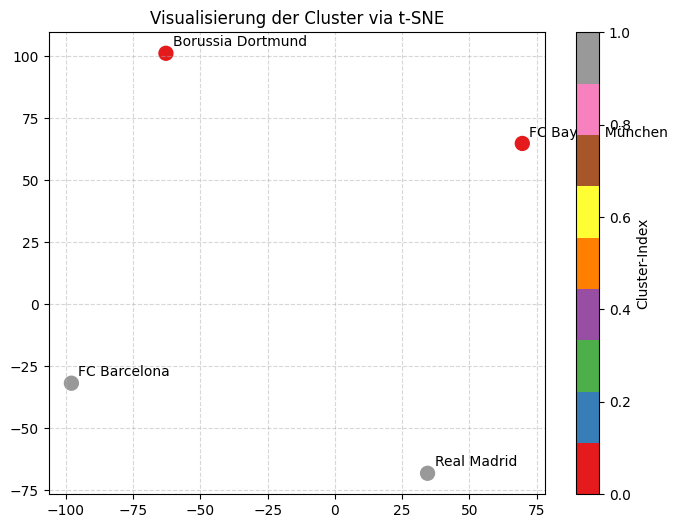

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. t-SNE initialisieren: Reduktion auf 2 Komponenten (X und Y für das Diagramm)
tsne = TSNE(n_components=2, perplexity=3, random_state=42)
X_embedded = tsne.fit_transform(X.toarray()) # X ist deine TF-IDF-Matrix

# 2. Die neuen 2D-Koordinaten in dein Ergebnis-DataFrame packen
ergebnis_df["x"] = X_embedded[:, 0]
ergebnis_df["y"] = X_embedded[:, 1]

# 3. Das Diagramm zeichnen
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    ergebnis_df["x"], 
    ergebnis_df["y"], 
    c=ergebnis_df["Zugeordnetes_Cluster"], # KORREKTUR: Unterstrich hinzugefügt!
    cmap="Set1", 
    s=100
)

# Vereinsnamen als Text an die Punkte schreiben
for i, team in enumerate(ergebnis_df["Verein"]):
    ax.annotate(
        team, 
        (ergebnis_df["x"].iloc[i], ergebnis_df["y"].iloc[i]), 
        xytext=(5, 5), 
        textcoords="offset points"
    )

plt.title("Visualisierung der Cluster via t-SNE")
plt.colorbar(scatter, label="Cluster-Index") # Optional: Zeigt eine Legende für die Farben
plt.grid(True, linestyle="--", alpha=0.5) 
plt.show()


#### Version 2 mit Topics

c:\Users\Annette\00_Data_Science\06_NLP_GenAI\05_sandbox_task_2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128194 (\N{OPEN FILE FOLDER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


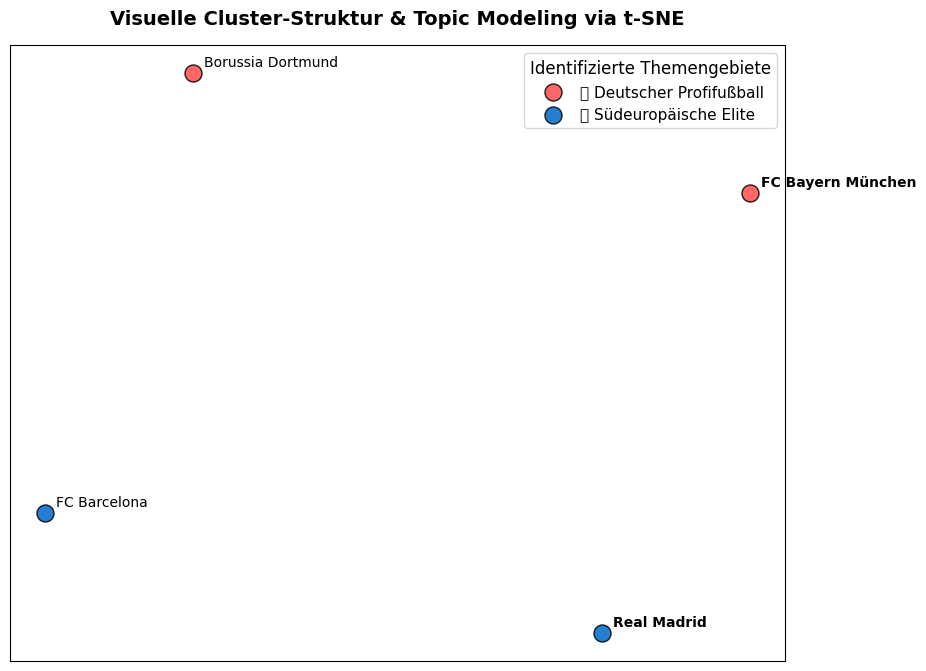

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. t-SNE Berechnung (wie gehabt)
tsne = TSNE(n_components=2, perplexity=3, random_state=42)
X_embedded = tsne.fit_transform(X.toarray())

ergebnis_df["x"] = X_embedded[:, 0]
ergebnis_df["y"] = X_embedded[:, 1]

# 2. Definieren eines Wörterbuch (Dictionary) mit den echten Topic-Namen
cluster_topics = {
    0: "Deutscher Profifußball",
    1: "Südeuropäische Elite",
    # Falls k=3 eingestellt ist, hier erweitern: 2: "Fokus Premier League"
}

# 3. Diagramm erstellen
fig, ax = plt.subplots(figsize=(10, 8))

# jedes Cluster einzeln in einer Schleife, 
# damit jedem Cluster sein eigenes Topic-Label geben werden kann
colors = ["#ff4b4b", "#0068c9", "#83c83f", "#fca000"] # Schöne, klare Streamlit-Farben

for cluster_idx in sorted(ergebnis_df["Zugeordnetes_Cluster"].unique()):
    # Filtere das DataFrame nur nach dem aktuellen Cluster
    cluster_data = ergebnis_df[ergebnis_df["Zugeordnetes_Cluster"] == cluster_idx]
    
    # Hole den Topic-Namen aus dem Wörterbuch (Fallback falls nicht vorhanden)
    topic_name = cluster_topics.get(cluster_idx, f"Cluster {cluster_idx}")
    
    # Zeichne die Punkte für dieses spezifische Cluster
    ax.scatter(
        cluster_data["x"], 
        cluster_data["y"], 
        label=f"📂 {topic_name}", # Das Topic wird das Label für die Legende!
        color=colors[cluster_idx % len(colors)],
        s=150,                 # Etwas größere Punkte für bessere Sichtbarkeit
        alpha=0.85,
        edgecolors="black"      # Ein feiner schwarzer Rand um die Punkte
    )

# 4. Vereinsnamen an die Punkte schreiben
for i, team in enumerate(ergebnis_df["Verein"]):
    ax.annotate(
        team, 
        (ergebnis_df["x"].iloc[i], ergebnis_df["y"].iloc[i]), 
        xytext=(8, 5), 
        textcoords="offset points",
        fontsize=10,
        weight="bold" if "Bayern" in team or "Real" in team else "normal" # Akzente setzen
    )

# 5. Styling & Legende hinzufügen
plt.title("Visuelle Cluster-Struktur & Topic Modeling via t-SNE", fontsize=14, pad=15, weight="bold")
plt.legend(loc="upper right", fontsize=11, title="Identifizierte Themengebiete", title_fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)

# Achsenbeschriftungen entfernen, da t-SNE-Koordinaten selbst keine physikalische Maßeinheit haben
ax.set_xticks([])
ax.set_yticks([])

plt.show()